<a href="https://colab.research.google.com/github/hursoo/big_k-modern_1/blob/main/gb_131_writer_networks(big1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.개요 및 기본 설정
- 필자 연결망의 구조 변화
- 필자 그룹별 토픽 연결망의 차이

In [1]:
# =================================================================
# 셀 1: 필수 라이브러리 및 한글 폰트 설치
# =================================================================
# ⚠️ 이 셀을 실행한 후에는 반드시 "런타임 다시 시작"을 해야 합니다.

# 1. 라이브러리 설치 (최신 호환 버전)
!pip install -q tomotopy kneed

# 2. 나눔 폰트 설치
!sudo apt-get -qq install fonts-nanum*

# 3. 폰트 캐시 재생성
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

print("✅ 라이브러리 및 한글 폰트 설치가 완료되었습니다.")
print("🔴 중요: 지금 바로 메뉴에서 [런타임] > [세션 다시 시작]을 실행하세요!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 45.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
o

Mounted at /content/drive

✅ 구글 드라이브 마운트 완료!
1.26.4
✅ 기본 설정 및 라이브러리 임포트 완료!


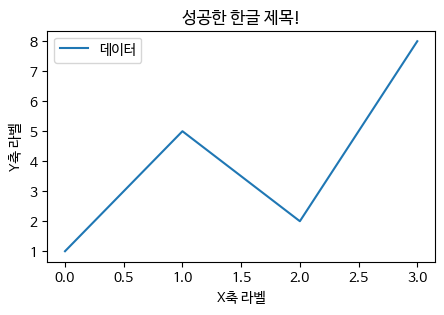

In [1]:
# =================================================================
# 셀 2: 기본 설정 및 라이브러리 임포트
# =================================================================
# "세션 다시 시작" 후에 이 셀부터 실행합니다.

# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')
print("\n✅ 구글 드라이브 마운트 완료!")

# 경로 지정
file_path = '/content/drive/MyDrive/big_km_history01/'

# 라이브러리 임포트
import sys
import os, re
import pandas as pd
import numpy as np
print(np.__version__)
import random
import warnings

from tomotopy import DMRModel
from tomotopy import TermWeight
from tomotopy import utils
import tomotopy as tp

# ⚠️ 한글 폰트 설정 코드를 여기에 배치합니다.
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic') # 나눔바른고딕으로 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("✅ 기본 설정 및 라이브러리 임포트 완료!")

# 그래프 한글 표시 테스트
plt.figure(figsize=(5, 3))
plt.title('성공한 한글 제목!')
plt.xlabel('X축 라벨')
plt.ylabel('Y축 라벨')
plt.plot([1, 5, 2, 8], label='데이터')
plt.legend()
plt.show()

# 2.데이터 불러오기

In [2]:
# 통합 데이터 불러오기
df = pd.read_excel(file_path + 'result/gb_data_2(doc,1g2g,wn_cls).xlsx') ###
df[:3]
# 1기, 2기: doc_id는 3046부터 끝까지
df['period'] = np.where(
    df['doc_id'] < 3046,  # 조건
    'p1',                          # 조건이 참일 때
    'p2'                           # 조건이 거짓일 때
)
df

,doc_id,doc_raw,doc_split_12gram,r_no,title,w_new,ho_no,grid_1,wn_cls,period
0,1,創刊辭 强者도 부르짖고 弱者도 부르짖으며 優者도 부르짖고 劣者도 부르짖도다 東西南北...,창간 辭 강자 약자 優者 劣者 동서 남북 사해 팔방 소리 소리 판단 좌우 間 다수 ...,1,創刊辭,uk01,1,01q,0,p1
1,2,哲人은 말하되 多數 人民의 聲은 곳 神의 聲이라 하엿나니 神은 스스로 要求가 없는지...,哲人 다수 인민 요구 인민 소리 요구 발표 갈앙 인민 소리 갈앙 다수 인민 갈앙 요...,1,創刊辭,uk01,1,01q,0,p1
2,3,世界를 알라 사람은 天使도 안이며 野獸도 안이오 오즉 사람일 뿐이로다 이만치 進化된...,세계 사람 야수 사람 진화 진화 지식 진화 도덕 동물 세계 천당 지옥 세계 진화 국...,2,世界를 알라,uk01,1,01q,0,p1
3,4,사람과 世界는 決코 논하볼 것이 안이엇다 사람으로 된 世界 世界로 된 사람 둘이 안...,사람 세계 사람 세계 세계 사람 세계 대표 시대 가치 사람 대표 문화 상징 符號 사...,2,世界를 알라,uk01,1,01q,0,p1
4,5,過去는 論할 것이 업도다만은 今日과 가티 交通이 이마마하고 知識이 이마마하고 一切의...,過去 금일 교통 지식 일체 문물 오늘 세계 理解 공자 천하 천하 理解 오늘 날 사람...,2,世界를 알라,uk01,1,01q,0,p1
...,...,...,...,...,...,...,...,...,...,...
6797,6798,미국에서는 每人에게 奴僕이 식 돌아감니다 단 機械奴僕만 이건 무슨 말이냐 하면 기계...,미국 노복 機械 노복 機械 力 운전 계산 人力 계산 미국 국민 사람 機械 輸入 숫자...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6798,6799,매년 저축은ㅡ필요의 비용을 다 쓴 뒤의 것 말이지요ㅡ매년에 억 딸라 金 루불로는 억...,저축 필요 비용 미국 교과 書 실상 미국 富豪 캐나다 영국 미국 부분 미국 캐나다 ...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6799,6800,그러고 또 캐나다는 아조 겸손스럽게 좀 유순하게 미국의 北邊繼續이라고ㅡ국제연맹의 축...,캐나다 미국 국제_연맹 국제_연맹 원인 경제 機械 캐나다 산업 북미 자본 점령 부분...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6800,6801,25년 전에는 영국이 美보다 배나 더 되게 輸入하엿섯음니다 캐나다 사람들은 지금 그...,영국 미국 輸入 캐나다 사람 영국 一部 미국 호주 캐나다 진화 호주 일본 침입 보호...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2


In [17]:
# 저장

df.to_excel(file_path + 'result/gb_data_2(doc,1g2g,wn_cls)_period.xlsx')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6802 entries, 0 to 6801
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   doc_id            6802 non-null   int64 
 1   doc_raw           6802 non-null   object
 2   doc_split_12gram  6802 non-null   object
 3   r_no              6802 non-null   int64 
 4   title             6802 non-null   object
 5   w_new             6802 non-null   object
 6   ho_no             6802 non-null   int64 
 7   grid_1            6802 non-null   object
 8   wn_cls            6802 non-null   int64 
 9   period            6802 non-null   object
dtypes: int64(4), object(6)
memory usage: 531.5+ KB


# 3.1,2기 필자 연결망 비교

## 3.1.'문서별 토픽비중' 불러오기
- doc-distrib.txt

In [4]:
# -*- coding: utf-8 -*-
# 개벽 주요논설 DMR 문서-토픽 분포 → 기간별(1기/2기) 토픽-토픽 코사인유사도 기반 네트워크 시각화

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import re
from pathlib import Path

In [5]:
# 문서별 토픽비중 불러오기

doc_dist = pd.read_csv(file_path + 'result/doc-distrib.txt', sep='\t')
doc_dist.drop(columns=['Unnamed: 0'], inplace=True)
doc_dist['doc_id'] = doc_dist.index + 1
doc_dist.set_index('doc_id', inplace=True)
doc_dist

,T0,T1,T2,T3,T4,T5,T6,T7
doc_id,,,,,,,,
1,0.100175,0.000584,0.005788,0.000916,0.699498,0.007016,0.181811,0.004213
2,0.242115,0.000204,0.016817,0.000319,0.022108,0.313191,0.403775,0.001470
3,0.013623,0.000518,0.005135,0.000812,0.357190,0.570561,0.048423,0.003738
4,0.170529,0.000538,0.005336,0.000844,0.058408,0.671052,0.089409,0.003884
5,0.701495,0.000366,0.003632,0.000575,0.066367,0.217282,0.007639,0.002644
...,...,...,...,...,...,...,...,...
6798,0.003296,0.014734,0.604653,0.085668,0.000684,0.001389,0.163286,0.126290
6799,0.004578,0.020463,0.062022,0.007873,0.000949,0.001929,0.449007,0.453179
6800,0.003746,0.016743,0.232563,0.051896,0.000777,0.001578,0.003735,0.688963


In [6]:
name = df[['doc_id', 'w_new']]
name.set_index(['doc_id'],inplace=True)
name

,w_new
doc_id,
1,uk01
2,uk01
3,uk01
4,uk01
5,uk01
...,...
6798,김철산
6799,김철산
6800,김철산


In [7]:
doc_dist_w = pd.concat([doc_dist, name], axis=1)
doc_dist_w

,T0,T1,T2,T3,T4,T5,T6,T7,w_new
doc_id,,,,,,,,,
1,0.100175,0.000584,0.005788,0.000916,0.699498,0.007016,0.181811,0.004213,uk01
2,0.242115,0.000204,0.016817,0.000319,0.022108,0.313191,0.403775,0.001470,uk01
3,0.013623,0.000518,0.005135,0.000812,0.357190,0.570561,0.048423,0.003738,uk01
4,0.170529,0.000538,0.005336,0.000844,0.058408,0.671052,0.089409,0.003884,uk01
5,0.701495,0.000366,0.003632,0.000575,0.066367,0.217282,0.007639,0.002644,uk01
...,...,...,...,...,...,...,...,...,...
6798,0.003296,0.014734,0.604653,0.085668,0.000684,0.001389,0.163286,0.126290,김철산
6799,0.004578,0.020463,0.062022,0.007873,0.000949,0.001929,0.449007,0.453179,김철산
6800,0.003746,0.016743,0.232563,0.051896,0.000777,0.001578,0.003735,0.688963,김철산


In [8]:
# 시기별 필자-토픽분포

doc_dist_w_1p = doc_dist_w.query('doc_id < 3046')
doc_dist_w_2p = doc_dist_w.query('doc_id >= 3046')
doc_dist_w_1p

,T0,T1,T2,T3,T4,T5,T6,T7,w_new
doc_id,,,,,,,,,
1,0.100175,0.000584,0.005788,0.000916,0.699498,0.007016,0.181811,0.004213,uk01
2,0.242115,0.000204,0.016817,0.000319,0.022108,0.313191,0.403775,0.001470,uk01
3,0.013623,0.000518,0.005135,0.000812,0.357190,0.570561,0.048423,0.003738,uk01
4,0.170529,0.000538,0.005336,0.000844,0.058408,0.671052,0.089409,0.003884,uk01
5,0.701495,0.000366,0.003632,0.000575,0.066367,0.217282,0.007639,0.002644,uk01
...,...,...,...,...,...,...,...,...,...
3041,0.870754,0.000178,0.018285,0.000477,0.060587,0.015685,0.032269,0.001766,이동곡
3042,0.853321,0.000636,0.012838,0.001699,0.006610,0.003573,0.010346,0.110977,이동곡
3043,0.977144,0.000346,0.006987,0.000925,0.003597,0.001945,0.005631,0.003426,이동곡


In [9]:
wdist_1p = doc_dist_w_1p.groupby('w_new').mean()
wdist_2p = doc_dist_w_2p.groupby('w_new').mean()
wdist_1p

,T0,T1,T2,T3,T4,T5,T6,T7
w_new,,,,,,,,
uk01,0.230434,0.005496,0.055514,0.009419,0.354093,0.165355,0.090292,0.089396
uk02,0.128980,0.019443,0.025894,0.008798,0.147321,0.248834,0.413226,0.007504
uk03,0.279148,0.017629,0.009942,0.001257,0.146821,0.193968,0.301790,0.049445
uk04,0.281844,0.180753,0.018646,0.022757,0.131489,0.109123,0.243193,0.012195
uk05,0.265345,0.007132,0.082599,0.035210,0.182828,0.070590,0.240147,0.116149
강인택,0.099125,0.545539,0.028000,0.005508,0.081040,0.199141,0.037649,0.003996
김규호,0.029654,0.000194,0.795926,0.001583,0.007997,0.001089,0.010625,0.152933
김기전,0.156260,0.020318,0.135641,0.015423,0.268552,0.115858,0.256824,0.031125
김병준,0.464714,0.097056,0.016493,0.001333,0.131773,0.046854,0.217741,0.024036


In [10]:
wdist_2p

,T0,T1,T2,T3,T4,T5,T6,T7
w_new,,,,,,,,
BSL생,0.008009,0.001694,0.631751,0.182031,0.034330,0.036385,0.098106,0.007693
O民,0.148086,0.005180,0.142894,0.444095,0.015698,0.065906,0.069980,0.108160
PSL생,0.015660,0.000468,0.328062,0.082563,0.032324,0.254976,0.231717,0.054230
XY生,0.218922,0.003152,0.035827,0.231521,0.010857,0.143946,0.316915,0.038861
uk06,0.141573,0.001672,0.113801,0.110865,0.185505,0.086834,0.279658,0.080093
...,...,...,...,...,...,...,...,...
최남선,0.116606,0.041042,0.053951,0.036212,0.004743,0.179526,0.565704,0.002215
최화운,0.024185,0.002334,0.024735,0.266034,0.029310,0.627389,0.001530,0.024483
허죽재,0.105060,0.013010,0.142681,0.051625,0.158957,0.227310,0.234854,0.066503


In [12]:
# 저장
wdist_1p.to_csv(file_path + 'result/wdist_1p.csv')
wdist_2p.to_csv(file_path + 'result/wdist_2p.csv')

## 3.2.필자 연결망 그래프

In [14]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics.pairwise import cosine_similarity
import csv

# 1. 한글 폰트 설치 (Colab 런타임 새로 시작 시 필수)
!sudo apt-get -y install fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
# 런타임을 다시 시작해주세요! [런타임] > [런타임 다시 시작]

# 2. 폰트 설정
# 런타임 다시 시작 후, 이 셀부터 실행
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
print("✅ 나눔고딕 폰트가 설정되었습니다.")

# --- 데이터 로딩 및 전처리 ---
try:
    # file_path = '/content/drive/MyDrive/big_km_history01/'
    df_1p = pd.read_csv(file_path + 'result/wdist_1p.csv', index_col='w_new')
    df_2p = pd.read_csv(file_path + 'result/wdist_2p.csv', index_col='w_new')

    cls_data_path = file_path + 'result/gb_data_2(doc,1g2g,wn_cls)_period.xlsx'
    df_cls = pd.read_excel(cls_data_path, usecols=['w_new', 'wn_cls'])
    df_cls['wn_cls'] = pd.to_numeric(df_cls['wn_cls'], errors='coerce')
    author_cls = df_cls.dropna().drop_duplicates().set_index('w_new')

    df_1p_merged = df_1p.join(author_cls, how='left')
    df_2p_merged = df_2p.join(author_cls, how='left')

    print("✅ 모든 데이터를 성공적으로 불러오고 병합했습니다.")
except NameError:
    print("❗️오류: 'file_path' 변수가 정의되지 않았습니다. 파일이 있는 경로를 지정해주세요.")
except FileNotFoundError as e:
    print(f"❗️오류: 파일을 찾을 수 없습니다. {e.filename}")
except Exception as e:
    print(f"❗️데이터 처리 중 오류가 발생했습니다: {e}")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [15]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def analyze_group_centroids(df_merged, title, cls_map):
    """
    그룹별 '원형(Centroid)'을 계산하고
    각 필자와 원형 간의 유사도를 분석하는 함수
    """
    print(f"\n{'='*50}")
    print(f"--- {title} 그룹 원형(Centroid) 분석 ---")
    print(f"{'='*50}")

    # 1. wn_cls를 제외한 토픽 컬럼만 추출
    # (T0, T1, ... T7 등의 컬럼)
    topic_cols = [col for col in df_merged.columns if col not in ['wn_cls']]

    # 2. 그룹별 평균 토픽 벡터(Centroid) 계산
    # 'wn_cls'로 그룹화하여 토픽 컬럼들의 평균을 냅니다.
    group_centroids = df_merged.groupby('wn_cls')[topic_cols].mean()

    print("\n[1. 그룹별 평균 토픽 벡터 (Centroids)]")
    # cls_map을 사용하여 인덱스 이름 변경 (예: 1 -> '개벽 주도층')
    group_centroids = group_centroids.rename(index=cls_map)
    print(group_centroids)

    # 3. 분석할 그룹의 원형(Centroid)을 별도 변수로 저장
    # (cls_map에 정의된 이름 기준)
    try:
        centroid_cls1 = group_centroids.loc[cls_map[1]]
        centroid_cls2 = group_centroids.loc[cls_map[2]]
    except KeyError:
        print("\n❗️오류: 클래스 1 또는 2가 데이터에 없습니다. 2기 분석을 건너뜁니다.")
        return
    except Exception as e:
        print(f"\n❗️오류 발생: {e}. 2기 분석을 건너뜁니다.")
        return

    # 4. 개별 필자 vs. 그룹 원형 간 유사도 계산
    results = []

    # df_merged에서 클래스 1 또는 2에 속하는 필자만 반복
    for author, data in df_merged[df_merged['wn_cls'].isin([1, 2])].iterrows():
        author_vector = data[topic_cols].values.reshape(1, -1)
        author_cls = data['wn_cls']

        # 코사인 유사도 계산
        sim_to_cls1 = cosine_similarity(author_vector, centroid_cls1.values.reshape(1, -1))[0][0]
        sim_to_cls2 = cosine_similarity(author_vector, centroid_cls2.values.reshape(1, -1))[0][0]

        results.append({
            '필자': author,
            '분류': cls_map.get(author_cls, f"Class {author_cls}"),
            '유사도(vs 개벽주도층)': sim_to_cls1,
            '유사도(vs 사회주의자)': sim_to_cls2,
            '원래_분류': author_cls
        })

    # 5. 결과 DataFrame 생성
    results_df = pd.DataFrame(results)

    # 6. "가장 전형적인 필자" 찾기 (자신의 그룹 원형과 가장 유사한 필자)
    archetype_cls1 = results_df[results_df['원래_분류'] == 1].sort_values(by='유사도(vs 개벽주도층)', ascending=False)
    archetype_cls2 = results_df[results_df['원래_분류'] == 2].sort_values(by='유사도(vs 사회주의자)', ascending=False)

    print(f"\n[2. '개벽 주도층(1)'의 가장 전형적인 필자 Top 5]")
    print(" (='개벽 주도층' 평균 토픽과 가장 유사한 필자)")
    print(archetype_cls1[['필자', '유사도(vs 개벽주도층)']].head())

    print(f"\n[3. '사회주의자(2)'의 가장 전형적인 필자 Top 5]")
    print(" (='사회주의자' 평균 토픽과 가장 유사한 필자)")
    print(archetype_cls2[['필자', '유사도(vs 사회주의자)']].head())

    # 7. "경계에 선 필자" 찾기 (자신의 그룹보다 *다른* 그룹 원형에 더 가까운 필자)
    borderline_cls1 = results_df[
        (results_df['원래_분류'] == 1) &
        (results_df['유사도(vs 사회주의자)'] > results_df['유사도(vs 개벽주도층)'])
    ]

    borderline_cls2 = results_df[
        (results_df['원래_분류'] == 2) &
        (results_df['유사도(vs 개벽주도층)'] > results_df['유사도(vs 사회주의자)'])
    ]

    print(f"\n[4. 경계인 분석: '개벽 주도층(1)'이지만 '사회주의자(2)' 원형에 더 가까운 필자]")
    print(borderline_cls1[['필자', '유사도(vs 개벽주도층)', '유사도(vs 사회주의자)']].sort_values(by='유사도(vs 사회주의자)', ascending=False))

    print(f"\n[5. 경계인 분석: '사회주의자(2)'이지만 '개벽 주도층(1)' 원형에 더 가까운 필자]")
    print(borderline_cls2[['필자', '유사도(vs 개벽주도층)', '유사도(vs 사회주의자)']].sort_values(by='유사도(vs 개벽주도층)', ascending=False))
    print(f"{'='*50}\n")


# --- 함수 호출 예시 (이 코드를 3.2 섹션의 데이터 로딩 후 실행) ---

# 분석에 사용할 그룹 이름 정의
# (4.5 섹션의 group_map과 동일하게 사용)
group_map_2p = {1: '개벽주도층', 2: '사회주의자'}

# 'df_2p_merged' 변수가 로드된 후에 이 함수를 호출합니다.
# 'df_2p_merged'가 존재하는지 확인 후 실행
if 'df_2p_merged' in locals() and not df_2p_merged.empty:
    analyze_group_centroids(df_2p_merged, "2기 필자", group_map_2p)
else:
    print("❗️ 'df_2p_merged' 데이터가 준비되지 않아 2기 원형 분석을 건너뜁니다.")


--- 2기 필자 그룹 원형(Centroid) 분석 ---

[1. 그룹별 평균 토픽 벡터 (Centroids)]
              T0        T1        T2        T3        T4        T5        T6  \
wn_cls                                                                         
0       0.133340  0.048909  0.088949  0.189679  0.074668  0.080871  0.273449   
개벽주도층   0.056509  0.201082  0.116483  0.085085  0.106748  0.134949  0.224290   
사회주의자   0.114552  0.013809  0.155497  0.343312  0.043489  0.106521  0.079536   
3       0.116126  0.047667  0.131589  0.189098  0.085069  0.185774  0.146427   

              T7  
wn_cls            
0       0.110135  
개벽주도층   0.074853  
사회주의자   0.143284  
3       0.098249  

[2. '개벽 주도층(1)'의 가장 전형적인 필자 Top 5]
 (='개벽 주도층' 평균 토픽과 가장 유사한 필자)
     필자  유사도(vs 개벽주도층)
2   김기전       0.831916
6   박달성       0.761709
14  이돈화       0.660102
18  차상찬       0.634590

[3. '사회주의자(2)'의 가장 전형적인 필자 Top 5]
 (='사회주의자' 평균 토픽과 가장 유사한 필자)
     필자  유사도(vs 사회주의자)
0    O民       0.976613
15  이성태       0.975844
4   김명식       0.953569
17 


--- [1기 필자 연결망 (분류 적용)] 매개 중심성 (상위 10명) ---
 (서로 다른 집단을 연결하는 '다리' 역할의 중요도) 
uk01     0.083334
동양실주인    0.050376
임규       0.037966
이종린      0.037696
이돈화      0.035593
uk04     0.026339
uk05     0.022844
uk03     0.021693
김기전      0.019892
신식       0.018419
dtype: float64
-------------------------------------
✅ '1기_필자_연결망_(분류_적용)_colored.png' 파일로 색상이 적용된 그래프가 저장되었습니다.


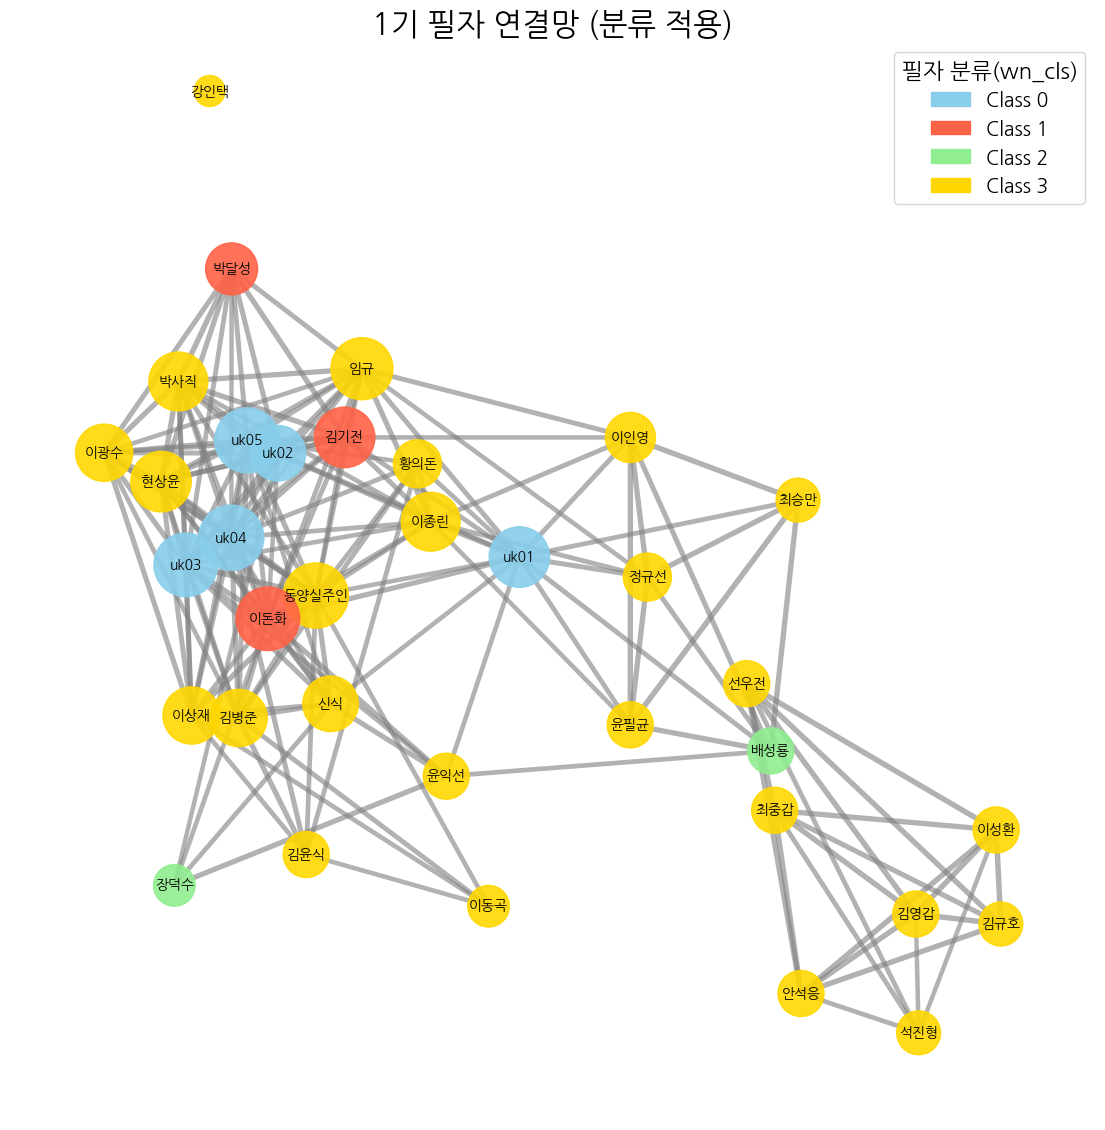


--- [2기 필자 연결망 (분류 적용)] 매개 중심성 (상위 10명) ---
 (서로 다른 집단을 연결하는 '다리' 역할의 중요도) 
김경재      0.163328
uk08     0.119741
반구실주인    0.117626
박형병      0.082517
월평인      0.080679
허죽재      0.080574
XY生      0.074920
정지현      0.072399
박헌영      0.071965
임장화      0.069612
dtype: float64
-------------------------------------
✅ '2기_필자_연결망_(분류_적용)_colored.png' 파일로 색상이 적용된 그래프가 저장되었습니다.


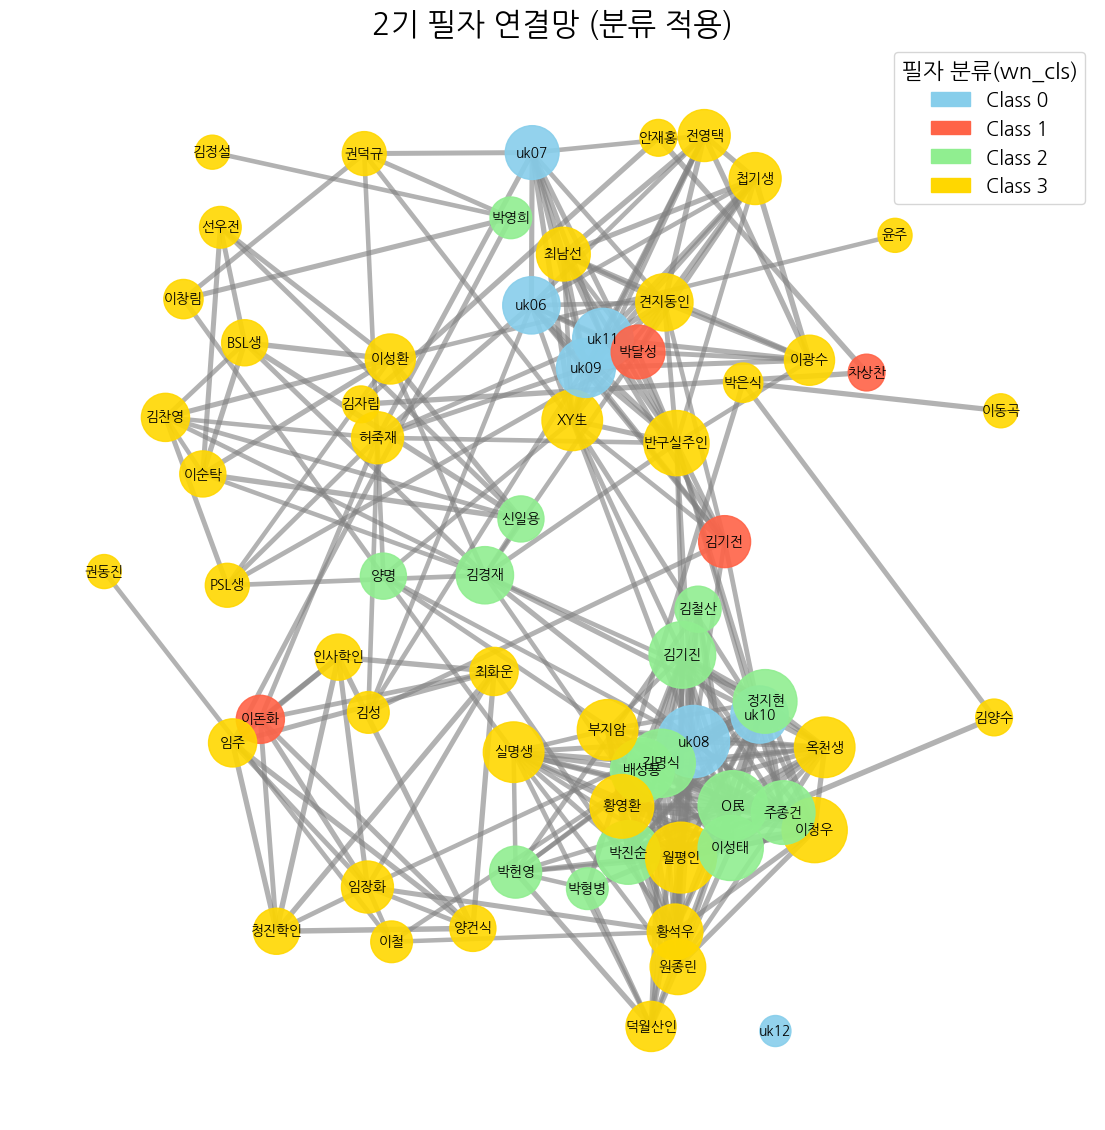

In [16]:
# --- 네트워크 시각화 함수 정의 ---
def create_and_visualize_network_with_colors(df, title, similarity_threshold=0.8):
    if df.empty:
        return

    topic_df = df.drop(columns=['wn_cls'])
    G = nx.Graph()
    authors = topic_df.index

    similarity_matrix = cosine_similarity(topic_df)
    sim_df = pd.DataFrame(similarity_matrix, index=authors, columns=authors)

    for author in authors:
        G.add_node(author, cls=df.loc[author, 'wn_cls'])

    for i in range(len(authors)):
        for j in range(i + 1, len(authors)):
            author1, author2 = authors[i], authors[j]
            if sim_df.loc[author1, author2] >= similarity_threshold:
                G.add_edge(author1, author2, weight=sim_df.loc[author1, author2])

    # --- [여기에 새 코드 추가 시작] ---
    # 1. 매개 중심성(Betweenness Centrality) 계산
    #    결과: {'필자A': 0.05, '필자B': 0.12, ...} 형태의 딕셔너리
    centrality = nx.betweenness_centrality(G)

    # 2. 딕셔너리를 Pandas Series로 변환하여 정렬
    sorted_centrality = pd.Series(centrality).sort_values(ascending=False)

    # 3. 결과 출력 (상위 10명)
    print(f"\n--- [{title}] 매개 중심성 (상위 10명) ---")
    print(" (서로 다른 집단을 연결하는 '다리' 역할의 중요도) ")
    print(sorted_centrality.head(10))
    print("-" * (len(title) + 20))
    # --- [새 코드 추가 끝] ---

    color_map = {0: 'skyblue', 1: 'tomato', 2: 'lightgreen', 3: 'gold', 4: 'plum', 5: 'khaki'}
    node_colors = [color_map.get(G.nodes[node]['cls'], 'grey') for node in G.nodes()]

    plt.figure(figsize=(14, 14))
    pos = nx.spring_layout(G, k=0.8, iterations=50, seed=42)
    node_degrees = [d * 100 + 500 for n, d in G.degree()]

    nx.draw_networkx_nodes(G, pos, node_size=node_degrees, node_color=node_colors, alpha=0.9)
    edge_weights = [d['weight'] * 4 for (u, v, d) in G.edges(data=True)]
    nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color='grey', alpha=0.6)

    # --- [최종 수정된 부분] ---
    # 라벨을 그리는 함수에 font_family를 직접 지정해줍니다.
    nx.draw_networkx_labels(G, pos, font_size=10, font_family='NanumGothic')

    cls_in_data = {G.nodes[node]['cls'] for node in G.nodes() if pd.notna(G.nodes[node]['cls'])}
    legend_handles = [mpatches.Patch(color=color_map.get(cls_val), label=f'Class {int(cls_val)}') for cls_val in sorted(cls_in_data)]
    plt.legend(handles=legend_handles, title='필자 분류(wn_cls)', fontsize=14, title_fontsize=16, loc='upper right')

    plt.title(title, fontsize=22)
    plt.axis('off')

    filename = title.replace(" ", "_") + "_colored.png"
    plt.savefig(filename, bbox_inches='tight')
    print(f"✅ '{filename}' 파일로 색상이 적용된 그래프가 저장되었습니다.")
    plt.show()


# --- 함수 호출 ---
if 'df_1p_merged' in locals():
    create_and_visualize_network_with_colors(df_1p_merged, title='1기 필자 연결망 (분류 적용)', similarity_threshold=0.8)
if 'df_2p_merged' in locals():
    create_and_visualize_network_with_colors(df_2p_merged, title='2기 필자 연결망 (분류 적용)', similarity_threshold=0.8)

# The End of Note